# Dasar-Dasar Klasifikasi dalam Machine Learning

Notebook ini berisi penjelasan komprehensif mengenai dasar-dasar klasifikasi, komponen utama, alur kerja, contoh dataset tiruan, hingga implementasi kode visualisasi untuk memahami bagaimana model memisahkan data berdasarkan kelasnya.

## 1. Apa itu Klasifikasi?

**Klasifikasi** adalah salah satu teknik utama dalam *Supervised Learning* (pembelajaran terawasi) di mana tujuannya adalah untuk memprediksi label atau kategori diskrit (kelas) dari suatu data berdasarkan fitur-fitur yang dimiliki.

Contoh populer:
- **Biner (2 Kelas):** Deteksi Spam (Spam vs. Bukan Spam), Diagnosis Penyakit (Sakit vs. Sehat).
- **Multi-kelas (>2 Kelas):** Klasifikasi jenis buah (Apel, Jeruk, Pisang), Pengenalan angka tulisan tangan (0 sampai 9).

## 2. Pembuatan Contoh Dataset: Prediksi Bermain Tenis

Mari kita buat contoh dataset sederhana yang sering digunakan untuk mempelajari dasar klasifikasi cuaca terhadap keputusan bermain tenis.

In [13]:
import pandas as pd
import numpy as np

# Membuat dataset tiruan untuk simulasi
data_random = {
    'Hari': [f'H{i}' for i in range(1, 15)], # Ditambah menjadi 14 data agar sebaran lebih terlihat
    'Outlook': ['Sunny', 'Rainy', 'Overcast', 'Sunny', 'Overcast', 'Rainy', 'Sunny', 'Rainy', 'Overcast', 'Sunny', 'Rainy', 'Overcast', 'Sunny', 'Rainy'],
    'Temperature': ['Hot', 'Mild', 'Hot', 'Cool', 'Mild', 'Cool', 'Mild', 'Hot', 'Cool', 'Hot', 'Mild', 'Hot', 'Cool', 'Mild'],
    'Humidity': ['High', 'Normal', 'High', 'Normal', 'High', 'High', 'Normal', 'Normal', 'Normal', 'High', 'High', 'Normal', 'High', 'Normal'],
    'Windy': [False, True, False, False, True, True, True, False, False, True, False, True, False, True],
    'Play': ['No', 'Yes', 'Yes', 'Yes', 'No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'No', 'No']
}

df = pd.DataFrame(data_random)
print("--- Dataset Prediksi Bermain Tenis ---")
df


--- Dataset Prediksi Bermain Tenis ---


,Hari,Outlook,Temperature,Humidity,Windy,Play
0,H1,Sunny,Hot,High,False,No
1,H2,Rainy,Mild,Normal,True,Yes
2,H3,Overcast,Hot,High,False,Yes
3,H4,Sunny,Cool,Normal,False,Yes
4,H5,Overcast,Mild,High,True,No
5,H6,Rainy,Cool,High,True,No
6,H7,Sunny,Mild,Normal,True,Yes
7,H8,Rainy,Hot,Normal,False,Yes
8,H9,Overcast,Cool,Normal,False,Yes
9,H10,Sunny,Hot,High,True,No


Dalam tabel di atas:
- **Fitur (Features):** `Outlook`, `Temperature`, `Humidity`, `Windy` (Variabel independen yang memengaruhi hasil).
- **Target / Label:** `Play` (Variabel dependen diskrit berupa kategori 'Yes' atau 'No' yang ingin diprediksi).

## 3. Visualisasi Konsep Dasar Klasifikasi (*Decision Boundary*)

Secara visual, tugas algoritma klasifikasi pada data numerik kontinyu adalah menemukan garis atau ruang pembatas (**Decision Boundary**) yang secara optimal dapat memisahkan titik-titik data dari kelas yang berbeda.

Di bawah ini adalah simulasi pembuatan data 2 Dimensi (2 Fitur) dengan 2 Kelas menggunakan Scikit-Learn untuk melihat bagaimana garis pembatas keputusan itu bekerja.

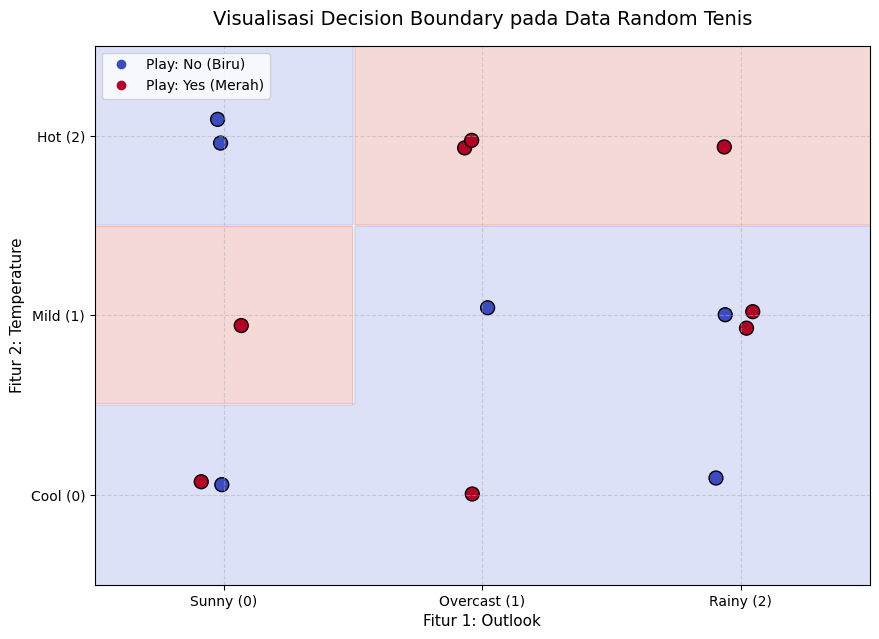

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier


# 2. Proses Encoding: Mengubah Teks menjadi Angka Numerik
# Kita buat mapping manual agar nilainya konsisten
outlook_map = {'Sunny': 0, 'Overcast': 1, 'Rainy': 2}
temp_map = {'Cool': 0, 'Mild': 1, 'Hot': 2}
play_map = {'No': 0, 'Yes': 1}

df['Outlook_Num'] = df['Outlook'].map(outlook_map)
df['Temp_Num'] = df['Temperature'].map(temp_map)
df['Play_Num'] = df['Play'].map(play_map)

# Kita pilih 2 fitur numerik ini sebagai X, dan Play sebagai y
X = df[['Outlook_Num', 'Temp_Num']].values
y = df['Play_Num'].values

# 3. Inisialisasi dan latih model classifier Decision Tree
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X, y)

# 4. Membuat grid mesh untuk menggambar area pembatas (Decision Boundary)
# Jarak min dan max disesuaikan dengan skala angka coding kita (0 sampai 2)
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

# Prediksi kelas untuk setiap titik pada grid
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# 5. Plotting Hasil Visualisasi
plt.figure(figsize=(10, 7))

# Mewarnai background area keputusan (Decision Boundary)
plt.contourf(xx, yy, Z, alpha=0.2, cmap=plt.cm.coolwarm)

# Menggambar scatter plot titik data asli dengan sedikit 'jitter' (pergeseran acak) 
# agar titik yang menumpuk di angka yang sama bisa terlihat menyebar
np.random.seed(42)
X_jitter = X + np.random.uniform(-0.1, 0.1, size=X.shape)
scatter = plt.scatter(X_jitter[:, 0], X_jitter[:, 1], c=y, edgecolors='k', cmap=plt.cm.coolwarm, s=100)

# Pengaturan Grafis Sumbu & Label
plt.title("Visualisasi Decision Boundary pada Data Random Tenis", fontsize=14, pad=15)

# Mengubah angka di sumbu X dan Y kembali menjadi label teks agar mudah dibaca
plt.xticks(ticks=[0, 1, 2], labels=['Sunny (0)', 'Overcast (1)', 'Rainy (2)'])
plt.yticks(ticks=[0, 1, 2], labels=['Cool (0)', 'Mild (1)', 'Hot (2)'])

plt.xlabel("Fitur 1: Outlook", fontsize=11)
plt.ylabel("Fitur 2: Temperature", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

# Menambahkan Legenda
plt.legend(handles=scatter.legend_elements()[0], labels=['Play: No (Biru)', 'Play: Yes (Merah)'], loc="upper left")

plt.show()

## 4. Evaluasi Hasil Klasifikasi

Setelah model membagi area keputusan di atas, performa model diukur menggunakan beberapa parameter utama seperti:
1. **Accuracy:** Total prediksi benar dibagi total seluruh data.
2. **Precision:** Keakuratan model dalam memprediksi label positif.
3. **Recall / Sensitivity:** Kemampuan model dalam menemukan kembali seluruh sampel berlabel positif.

In [19]:

# --- CARA 1: MENGUJI DENGAN DATA BARU ---

# Misal kita punya data cuaca baru untuk besok:
# Cuaca: Cerah/Sunny (0), Suhu: H1ot (2)
data_besok = [[0, 1]] 

# Meminta model melakukan prediksi
prediksi_besok = clf.predict(data_besok)

# Mengubah hasil prediksi angka (0 atau 1) kembali ke teks (No atau Yes)
hasil_teks = 'Yes' if prediksi_besok[0] == 1 else 'No'

print(f"Hasil Pengujian Data Baru:")
print(f"Jika Outlook=Sunny dan Temperature=Mild, Model memprediksi Play = {hasil_teks}")

Hasil Pengujian Data Baru:
Jika Outlook=Sunny dan Temperature=Mild, Model memprediksi Play = Yes
